In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import tifffile as tiff
import sys
sys.path.append("..")
sys.path.append("../models")

from models.baseline_Unet_ViT import U_net_ViT


In [2]:
class MicroCTDataset(Dataset):
    """
    Loads TIFF images and masks using tifffile so 16-bit intensities
    are NOT destroyed (PIL breaks 16-bit TIFFs).
    """

    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.img_files = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(".tif")
        ])

        self.mask_files = [
            f.replace(".tif", "").replace("image_v2_", "image_v2_mask_") + ".tif"
            for f in self.img_files
        ]

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        # --- LOAD TIFF PROPERLY (16-bit OK) ---
        img = tiff.imread(img_path)
        mask = tiff.imread(mask_path)

        # If 3D → pick center slice (same as your testing code)
        if img.ndim == 3:
            img = img[img.shape[0] // 2]
        if mask.ndim == 3:
            mask = mask[mask.shape[0] // 2]

        # --- Convert to float32 in [0,1] ---
        img = img.astype("float32")
        img = img / img.max()   # normalize safely

        mask = mask.astype("float32")
        mask = (mask > 0).astype("float32")  # binary mask

        # --- Convert to tensors ---
        img = torch.from_numpy(img).unsqueeze(0)  # shape: [1,H,W]
        mask = torch.from_numpy(mask).unsqueeze(0)

        # --- Apply augmentations ---
        if self.transform:
            data = torch.cat([img, mask], dim=0)  # [2,H,W]
            data = self.transform(data)
            img, mask = data[0].unsqueeze(0), data[1].unsqueeze(0)

        return img, mask


In [3]:
img_dir = "../datas/Original Images"
mask_dir = "../datas/Original Masks"

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(10),
])

dataset = MicroCTDataset(img_dir, mask_dir, transform=train_transform)

# 80/20 split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))


Train samples: 17
Val samples: 5


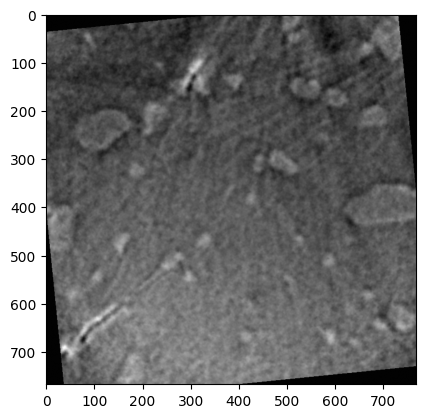

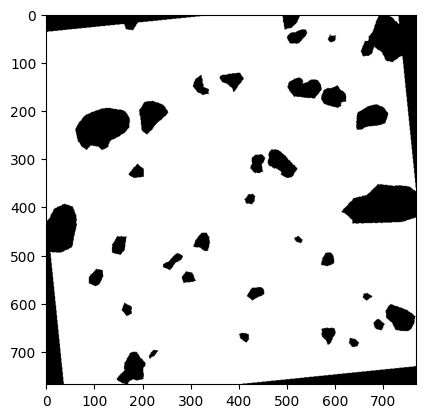

In [4]:
img, mask = dataset[0]
plt.imshow(img.squeeze().numpy(), cmap='gray')
plt.show()

plt.imshow(mask.squeeze().numpy(), cmap='gray')
plt.show()


In [5]:
class DiceLoss(nn.Module):          #Loss Functions (Dice + BCE)
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        smooth = 1e-6
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()
        return 1 - (2 * intersection + smooth) / (union + smooth)

criterion = lambda pred, target: (
    nn.BCEWithLogitsLoss()(pred, target) + DiceLoss()(pred, target)
)


In [6]:
#initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = U_net_ViT(
    encode_in=(1, 64, 128, 256),
    encode_out=(64, 128, 256, 512),
    decode_in=(1024, 512, 256, 128),
    decode_out=(512, 256, 128, 64),
    normalize=True
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Using device: cuda


In [7]:
#train
num_epochs = 2

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)

        optimizer.zero_grad()
        pred = model(img)
        print("[TRAIN DEBUG] pred logits:",
            pred.min().item(), pred.max().item(), pred.mean().item())

        _, _, ph, pw = pred.shape                    # crop mask to match pred spatial size 
        mask_cropped = mask[:, :, :ph, :pw]          # crop mask to match p red spatial size 

        loss = criterion(pred, mask_cropped)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(device), mask.to(device)
            pred = model(img)
            _, _, ph, pw = pred.shape                 # Crop validation mask to prediction size
            mask = mask[:, :, :ph, :pw]               # Crop validation mask to prediction size
            val_loss += criterion(pred, mask).item()  # Crop validation mask to prediction size

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

# Save model
torch.save(model.state_dict(), "../models/predicted_models/unet_vit_trained.pth")
print("Model saved ✔")


Size: torch.Size([4, 1, 768, 768])
Size: torch.Size([4, 64, 766, 766])
Size: torch.Size([4, 64, 764, 764])
[DEBUG] Encode block: min = 0.0 max = 45.63541793823242 mean = 0.43527957797050476 shape = (4, 64, 382, 382)
Size: torch.Size([4, 64, 382, 382])
Size: torch.Size([4, 128, 380, 380])
Size: torch.Size([4, 128, 378, 378])
[DEBUG] Encode block: min = 0.0 max = 35.82257843017578 mean = 0.5041937232017517 shape = (4, 128, 189, 189)
Size: torch.Size([4, 128, 189, 189])
Size: torch.Size([4, 256, 187, 187])
Size: torch.Size([4, 256, 185, 185])
[DEBUG] Encode block: min = 0.0 max = 30.036273956298828 mean = 0.5455970764160156 shape = (4, 256, 92, 92)
Size: torch.Size([4, 256, 92, 92])
Size: torch.Size([4, 512, 90, 90])
Size: torch.Size([4, 512, 88, 88])
[DEBUG] Encode block: min = 0.0 max = 29.880107879638672 mean = 0.6718481183052063 shape = (4, 512, 44, 44)
[DEBUG] Bottleneck output: min = -3.046757221221924 max = 6.415971755981445 mean = -3.0402677597685113e-10 shape = (4, 1024, 44, 44)


In [8]:
#Run inference on validation set + save results
import torchvision.transforms.functional as TF

save_dir = "../datas/predictions/"
os.makedirs(save_dir, exist_ok=True)

model.eval()
with torch.no_grad():
    for i, (img, _) in enumerate(val_loader):
        img = img.to(device)
        pred = torch.sigmoid(model(img)).cpu()
        pred_mask = (pred > 0.5).float()

        # Save as image
        out = TF.to_pil_image(pred_mask.squeeze(0))
        out.save(f"{save_dir}/pred_{i:03d}.tif")

print("Predictions saved ✔")


[DEBUG] Encode block: min = 0.0 max = 1.002824306488037 mean = 0.055856674909591675 shape = (1, 64, 382, 382)
[DEBUG] Encode block: min = 0.0 max = 0.5256991386413574 mean = 0.06966045498847961 shape = (1, 128, 189, 189)
[DEBUG] Encode block: min = 0.0 max = 0.39943602681159973 mean = 0.07325855642557144 shape = (1, 256, 92, 92)
[DEBUG] Encode block: min = 0.0 max = 0.5828754901885986 mean = 0.08923528343439102 shape = (1, 512, 44, 44)
[DEBUG] Bottleneck output: min = -2.754635810852051 max = 3.5888679027557373 mean = 1.176034038508078e-05 shape = (1, 1024, 44, 44)
[DEBUG] After bottleneck: min = -2.754635810852051 max = 3.5888679027557373 mean = 1.176034038508078e-05 shape = (1, 1024, 44, 44)
[DEBUG] Decode block: min = 0.0 max = 1.6902003288269043 mean = 0.193703755736351 shape = (1, 512, 84, 84)
[DEBUG] Decode block: min = 0.0 max = 0.5809395909309387 mean = 0.0814075618982315 shape = (1, 256, 164, 164)
[DEBUG] Decode block: min = 0.0 max = 0.5013421177864075 mean = 0.08899312466382

[DEBUG] Encode block: min = 0.0 max = 0.9927394986152649 mean = 0.05403907597064972 shape = (1, 64, 382, 382)
[DEBUG] Encode block: min = 0.0 max = 0.5111064314842224 mean = 0.06949444860219955 shape = (1, 128, 189, 189)
[DEBUG] Encode block: min = 0.0 max = 0.3960161507129669 mean = 0.07292336225509644 shape = (1, 256, 92, 92)
[DEBUG] Encode block: min = 0.0 max = 0.5769614577293396 mean = 0.0891462191939354 shape = (1, 512, 44, 44)
[DEBUG] Bottleneck output: min = -2.7524545192718506 max = 3.598936080932617 mean = 1.183373842650326e-05 shape = (1, 1024, 44, 44)
[DEBUG] After bottleneck: min = -2.7524545192718506 max = 3.598936080932617 mean = 1.183373842650326e-05 shape = (1, 1024, 44, 44)
[DEBUG] Decode block: min = 0.0 max = 1.6917378902435303 mean = 0.1940617710351944 shape = (1, 512, 84, 84)
[DEBUG] Decode block: min = 0.0 max = 0.5821457505226135 mean = 0.08143534511327744 shape = (1, 256, 164, 164)
[DEBUG] Decode block: min = 0.0 max = 0.5014702677726746 mean = 0.08921598643064

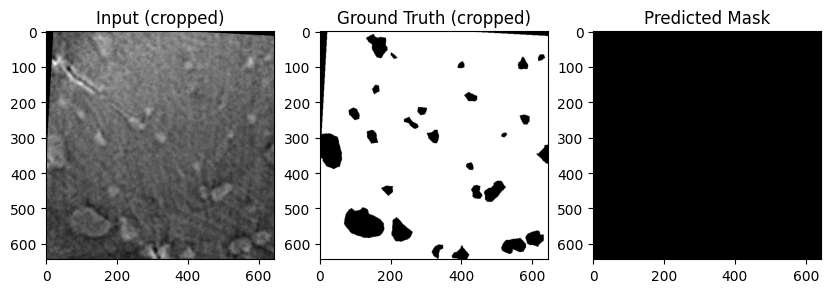

In [9]:
#disaplay results
sample_img, sample_mask = dataset[0]
model.eval()
with torch.no_grad():
    logits = model(sample_img.unsqueeze(0).to(device))
    print("[DEBUG] logits stats:", logits.min().item(), logits.max().item(), logits.mean().item())

    prob = torch.sigmoid(logits).cpu()

    # === CROP PREDICTION TO MATCH REAL SIZE ===
    _, _, ph, pw = prob.shape
    sample_img_cropped = sample_img[:, :ph, :pw]
    sample_mask_cropped = sample_mask[:, :ph, :pw]
    pred_mask = (prob > 0.5).float().squeeze(0).squeeze(0)

    print("[DEBUG] pred stats:", pred_mask.min().item(), pred_mask.max().item(), pred_mask.mean().item())

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(sample_img_cropped.squeeze(), cmap="gray")
plt.title("Input (cropped)")

plt.subplot(1,3,2)
plt.imshow(sample_mask_cropped.squeeze(), cmap="gray")
plt.title("Ground Truth (cropped)")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")


plt.show()


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

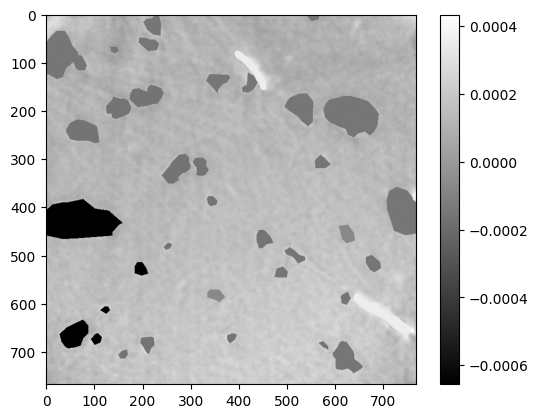

In [ ]:
#visulation of a mask.
raw = tiff.imread("../datas/Original Masks/image_v2_mask_00.tif")
plt.imshow(raw, cmap='gray')
plt.colorbar()
